<a href="https://colab.research.google.com/github/ProfAI/machine-learning-modelli-e-algoritmi/blob/main/5%20-%20Reti%20Neurali/neuralnetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Reti Neurali - il Multilayer Perceptron

Il **Multilayer Perceptron (MLP)** è il tipo fondamentale di rete neurale artificiale. È organizzato in strati di neuroni:

- **Input layer**: riceve le feature del dataset
- **Hidden layer(s)**: uno o più strati intermedi che apprendono rappresentazioni non lineari
- **Output layer**: produce la predizione finale

A differenza della Regressione Logistica (classificatore **lineare**), l'MLP può apprendere confini di decisione **non lineari**, rendendolo efficace su problemi che nessun modello lineare può risolvere. In questo notebook confronteremo i due approcci su un dataset non linearmente separabile.

### Importiamo i moduli

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Librerie importate:

- `make_moons` — genera dati sintetici non linearmente separabili
- `train_test_split` — divide i dati in training e test set
- `MinMaxScaler` — normalizza le feature nell'intervallo $[0, 1]$
- `LogisticRegression` — classificatore lineare usato come **baseline**
- `MLPClassifier` — il Multilayer Perceptron di scikit-learn (importato nella sezione dedicata)

In [2]:
!wget https://raw.githubusercontent.com/ProfAI/machine-learning-modelli-e-algoritmi/main/script/viz.py

--2026-06-21 19:24:40--  https://raw.githubusercontent.com/ProfAI/machine-learning-modelli-e-algoritmi/main/script/viz.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1088 (1.1K) [text/plain]
Saving to: ‘viz.py’

viz.py              100%[===================>]   1.06K  --.-KB/s    in 0s      

2026-06-21 19:24:41 (201 MB/s) - ‘viz.py’ saved [1088/1088]



In [3]:
from viz import plot_decision_boundary

### Definiamo le costanti

In [4]:
RANDOM_SEED = 0

Il `RANDOM_SEED` fissa il generatore di numeri casuali, garantendo la **riproducibilità** completa dell'esperimento: stessi dati generati, stesso split train/test e stessa inizializzazione dei pesi della rete neurale ad ogni esecuzione.

### Generiamo i dati

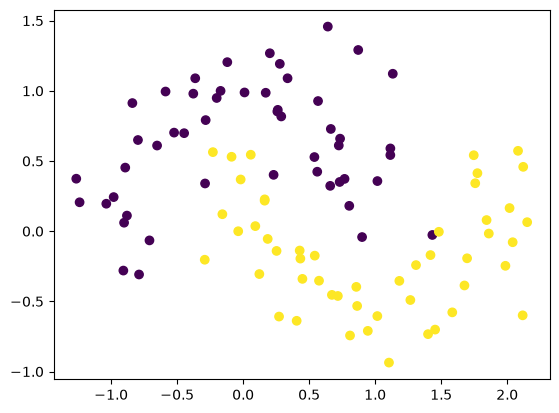

In [5]:
X, y = make_moons(n_samples=100, shuffle=True, noise=0.25, random_state=RANDOM_SEED)
plt.scatter(X[:,0], X[:,1], c=y)

`make_moons` genera 100 campioni distribuiti lungo **due semicerchi intrecciati** — un problema di classificazione binaria che nessun classificatore lineare può separare perfettamente.

Il parametro `noise=0.25` aggiunge rumore gaussiano, rendendo il problema più realistico. Il grafico mostra chiaramente la struttura non lineare dei dati.

### Processiamo i dati

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=RANDOM_SEED)

In [7]:
mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

**Perché scalare le feature?**

Le reti neurali addestrate con gradient descent sono sensibili alla scala dei valori. Feature su scale diverse causano gradienti instabili e convergenza lenta.

`MinMaxScaler` porta ogni feature nell'intervallo $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

> **Nota sul data leakage**: il `fit` è eseguito **solo sul training set** (`X_train`). Il test set è trasformato con i parametri del training — esattamente come accadrebbe in produzione con nuovi dati.

### Regressione Logistica

In [8]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.85

La Regressione Logistica raggiunge un'accuratezza dell'**85%** sul test set.

Essendo un modello **lineare**, il suo confine di decisione è una retta — strutturalmente inadeguata per il dataset `make_moons`. Questo 85% rappresenta il **tetto teorico** di un classificatore lineare su questi dati e sarà la nostra baseline di confronto.

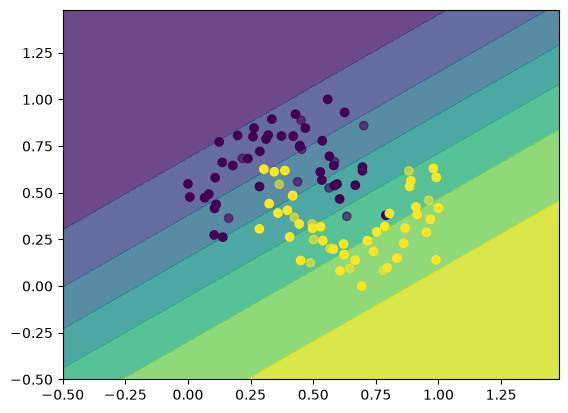

In [9]:
plot_decision_boundary(lr, (X_train, y_train), (X_test, y_test))

### Multilayer Perceptron

Il `MLPClassifier` di scikit-learn implementa una rete neurale feed-forward addestrata tramite **backpropagation** con il solver **Adam** (Adaptive Moment Estimation).

Funzione di attivazione di default: **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(x) = \max(0, x)$$

ReLU introduce la **non-linearità** che permette alla rete di apprendere confini di decisione curvilinei, superando il limite dei modelli lineari.

In [10]:
from sklearn.neural_network import MLPClassifier

In [11]:
mlp = MLPClassifier(hidden_layer_sizes=(100,100,100,), random_state=RANDOM_SEED)
mlp.fit(X_train, y_train)
mlp.score(X_test, y_test)

/home/rares/project/python/professionAI/machine-learning-modelli-e-algoritmi/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9

L'MLP con **3 strati nascosti da 100 neuroni** raggiunge **90% di accuratezza** — miglioramento netto rispetto all'85% della Regressione Logistica.

Architettura:

| Strato | Neuroni |
|--------|--------|
| Input | 2 |
| Hidden 1 | 100 (ReLU) |
| Hidden 2 | 100 (ReLU) |
| Hidden 3 | 100 (ReLU) |
| Output | 1 (sigmoid) |

> Il `ConvergenceWarning` indica che Adam non ha convergito entro le 200 iterazioni di default. Aumentare `max_iter` potrebbe migliorare ulteriormente le performance.

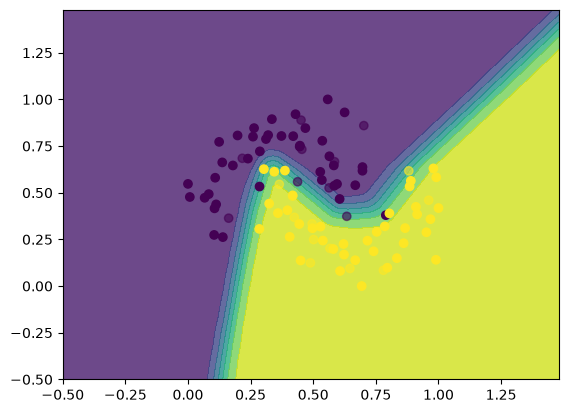

In [12]:
plot_decision_boundary(mlp, (X_train, y_train), (X_test, y_test))

In [13]:
len(mlp.coefs_)

4

In [14]:
len(mlp.intercepts_)

4

Con `hidden_layer_sizes=(100, 100, 100)` la rete ha **4 strati di connessioni** (3 hidden + 1 output), quindi 4 matrici di pesi (`coefs_`) e 4 vettori di bias (`intercepts_`):

| Connessione | Pesi | Bias |
|-------------|------|------|
| Input → Hidden 1 | 2 × 100 = 200 | 100 |
| Hidden 1 → Hidden 2 | 100 × 100 = 10.000 | 100 |
| Hidden 2 → Hidden 3 | 100 × 100 = 10.000 | 100 |
| Hidden 3 → Output | 100 × 1 = 100 | 1 |

**Totale**: ~20.401 parametri ottimizzati durante il training tramite backpropagation.

### A cosa serve la funzione di attivazione?

Senza funzione di attivazione non lineare, una rete profonda è **matematicamente equivalente a un modello lineare**.

**Dimostrazione**: la composizione di trasformazioni lineari rimane lineare:

$$W_3\bigl(W_2(W_1\mathbf{x} + b_1) + b_2\bigr) + b_3 = W'\mathbf{x} + b'$$

Useremo `activation='identity'` (nessuna trasformazione) su una rete con **10 strati nascosti** per dimostrare empiricamente che la profondità, senza non-linearità, non migliora il modello oltre la Regressione Logistica.

In [15]:
hiddel_layer_size = (100,)*10
mlp = MLPClassifier(hidden_layer_sizes=hiddel_layer_size, activation="identity", random_state=RANDOM_SEED)
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'identity'
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",0
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [16]:
weights = 0

for i in range(len(mlp.coefs_)):
  coefs =  mlp.coefs_[i].size
  bias = mlp.intercepts_[i].size
  tot = coefs+bias
  print(f"\tLayer {i} => pesi={coefs} bias={bias} totale={tot}")
  weights+=tot

print(f"\nPesi totali della rete={weights}")

	Layer 0 => pesi=200 bias=100 totale=300
	Layer 1 => pesi=10000 bias=100 totale=10100
	Layer 2 => pesi=10000 bias=100 totale=10100
	Layer 3 => pesi=10000 bias=100 totale=10100
	Layer 4 => pesi=10000 bias=100 totale=10100
	Layer 5 => pesi=10000 bias=100 totale=10100
	Layer 6 => pesi=10000 bias=100 totale=10100
	Layer 7 => pesi=10000 bias=100 totale=10100
	Layer 8 => pesi=10000 bias=100 totale=10100
	Layer 9 => pesi=10000 bias=100 totale=10100
	Layer 10 => pesi=100 bias=1 totale=101

Pesi totali della rete=91301


La rete con 10 strati da 100 neuroni e `activation='identity'` ha **91.301 parametri totali** — ma tutta questa capacità è sprecata: la rete apprende solo una trasformazione lineare.

Il confine di decisione visualizzato nella cella successiva sarà quasi identico a quello della Regressione Logistica, confermando che la **funzione di attivazione non lineare è il vero motore espressivo** delle reti neurali.

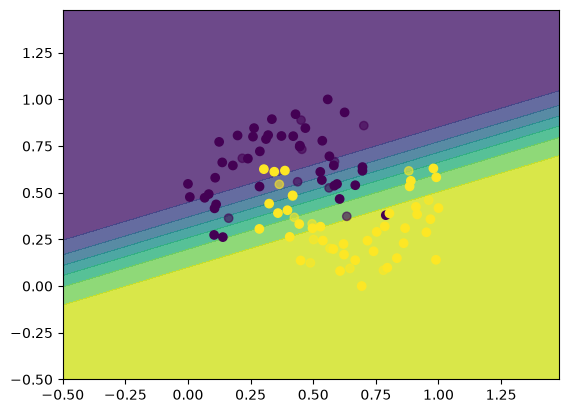

In [17]:
plot_decision_boundary(mlp, (X_train, y_train), (X_test, y_test))